In [39]:
from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *
from src.crypt_extraction import segment_organoid, split_villus_from_crypts, identify_neck_circumferences
from src.organoid_plotting import *
from src.cell_graph_functions import positive_indices_and_labels

In [40]:
def hks_to_curv_proxy_single_t(hks_col, t, d=2):
    """
    Convert a single HKS column (N,) at diffusion time t to a curvature-like target:
      Y_t = (6/t) * [ (4πt)^{d/2} * HKS_t - 1 ]  ~  Gaussian curvature
    Returns float32 (N,).
    """
    h = np.asarray(hks_col, dtype=np.float64).reshape(-1)
    t = float(t)
    Y = (6.0 / t) * ((4.0 * np.pi * t) ** (d / 2.0) * h - 1.0)
    return Y.astype(np.float32)


In [41]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm


BLACKLIST = { # Organoids with interior nodes
    "day3p5_B03_10",
    "day4_A02_44",
    "day4_A04_24",
    "day4_A04_90",
    "day4_A05_21",
    "day4_A05_53",
    "day4_B01_44",
    "day4_B01_70",
    "day4p5_A06_62",
    "day4p5_B06_128",
    "day4p5_B06_48",
    "day4p5-more_C01_5",
    "day4p5-more_C01_78",
    "day4p5-more_C02_27",
    "day4p5-more_C02_26",
    "day4p5-more_C02_35",
    "day4p5-more_C02_85",
    "day4p5-more_C02_88",
    "day4p5-more_C02_94",
    "day4p5-more_C02_127",
    "day4p5-more_C03_11",
    "day4p5-more_C03_17",
    "day4p5-more_C03_19",
    "day4p5-more_C03_45",
    "day4p5-more_C03_90",
    "day4p5-more_C03_96",
    "day4p5-more_C03_112",
    "day4p5-more_C03_137",
    "day4p5-more_C03_142",
    "day4p5-more_C04_14",
    "day4p5-more_C04_16",
    "day4p5-more_C04_22",
    "day4p5-more_C04_109",
    "day4p5-more_C05_127",
    "day4p5-more_C05_131",
    "day4p5-more_C05_142",
    "day4p5-more_C05_143",
    # the next are from Irene
    'day4p5-more_C01_138',
    'day4p5-more_C01_37', 
    'day4p5-more_C01_5',
    'day4p5-more_C01_53', 
    'day4p5-more_C01_78', 
    'day4p5-more_C01_93',
    'day4p5-more_C01_94', 
    'day4p5-more_C02_103', 
    'day4p5-more_C02_105',
    'day4p5-more_C02_127',
    'day4p5-more_C02_27',
    'day4p5-more_C02_35',
    'day4p5-more_C02_61',
    'day4p5-more_C02_77',
    'day4p5-more_C02_78',
    'day4p5-more_C02_85',
    'day4p5-more_C02_88',
    'day4p5-more_C02_94',
    'day4p5-more_C03_11',
    'day4p5-more_C03_110',
    'day4p5-more_C03_112',
    'day4p5-more_C03_135',
    'day4p5-more_C03_14',
    'day4p5-more_C03_149',
    'day4p5-more_C03_150',
    'day4p5-more_C03_152',
    'day4p5-more_C03_161',
    'day4p5-more_C03_166',
    'day4p5-more_C03_17',
    'day4p5-more_C03_171',
    'day4p5-more_C03_19',
    'day4p5-more_C03_30',
    'day4p5-more_C03_45',
    'day4p5-more_C03_60',
    'day4p5-more_C03_62',
    'day4p5-more_C03_64',
    'day4p5-more_C03_72',
    'day4p5-more_C03_86',
    'day4p5-more_C03_90',
    'day4p5-more_C03_96',
    'day4p5-more_C03_97',
    'day4p5-more_C04_109',
    'day4p5-more_C04_125',
    'day4p5-more_C04_132',
    'day4p5-more_C04_14',
    'day4p5-more_C04_16',
    'day4p5-more_C04_19',
    'day4p5-more_C04_22',
    'day4p5-more_C04_27',
    'day4p5-more_C04_30',
    'day4p5-more_C04_53',    
    'day4p5-more_C04_63', 
    'day4p5-more_C04_70', 
    'day4p5-more_C04_74',
    'day4p5-more_C04_75', 
    'day4p5-more_C04_76', 
    'day4p5-more_C04_80',
    'day4p5-more_C04_96', 
    'day4p5-more_C04_99', 
    'day4p5-more_C05_109',
    'day4p5-more_C05_127', 
    'day4p5-more_C05_131', 
    'day4p5-more_C05_142',
    'day4p5-more_C05_143', 
    'day4p5-more_C05_152', 
    'day4p5-more_C05_21',
    'day4p5-more_C05_4', 
    'day4p5-more_C05_42', 
    'day4p5-more_C05_43',
    'day4p5-more_C05_65', 
    'day4p5-more_C05_67', 
    'day4p5-more_C05_80',
    'day4p5-more_C05_82', 
    'day4p5-more_C05_94', 
    'day4p5-more_C06_100',
    'day4p5-more_C06_139', 
    'day4p5-more_C06_140', 
    'day4p5-more_C06_156',
    'day4p5-more_C06_166', 
    'day4p5-more_C06_175', 
    'day4p5-more_C06_177',
    'day4p5-more_C06_180',
}

# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'preprocessed')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

timepoints = timepoints[3:] # REMOVE DAY3

# --- Initialize container ---
HKS_list = []      # list of (n_cells, n_fields) arrays
label_uid_list = []
centroids_list = []
cell_graphs_list = []
t_HKS = [1.0, 2.0, 4.0, 8.0, 25.0]


for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    npz_files = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))
    if not npz_files:
        print(f"  ⚠ No .npz files found for {tp}, skipping.")
        continue

    for fpath in tqdm(npz_files, desc=f"{tp}"):
        try:
            data = np.load(fpath, allow_pickle=True)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
            # --- Basic data ---
            HKS_cell = data["fields_cell"]  # (n_cells, n_fields) e.g. HKS t=1,4,25
            cell_graph = load_cell_graph_from_npz(data)
            centroids = data['centroids']


            # --- Complexity ---
            well = str(data["well"])
            organoid_id = str(data["organoid_id"])
            label_uid = f"{tp}_{well}_{organoid_id}"

            # --- Blacklist check (EARLY EXIT) ---
            if label_uid in BLACKLIST:
                continue

            # --- Store ---
            HKS_list.append(HKS_cell) 
            label_uid_list.append(label_uid)
            centroids_list.append(centroids)
            cell_graphs_list.append(cell_graph)


        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue


Loaded 2668 complexity scores
Found 6 timepoints: ['day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day4 ===


day4: 100%|██████████| 357/357 [00:00<00:00, 950.51it/s] 



=== Processing timepoint: day4p5 ===


day4p5: 100%|██████████| 109/109 [00:00<00:00, 494.87it/s]



=== Processing timepoint: day4p5-more ===


day4p5-more: 100%|██████████| 534/534 [00:00<00:00, 1008.26it/s]


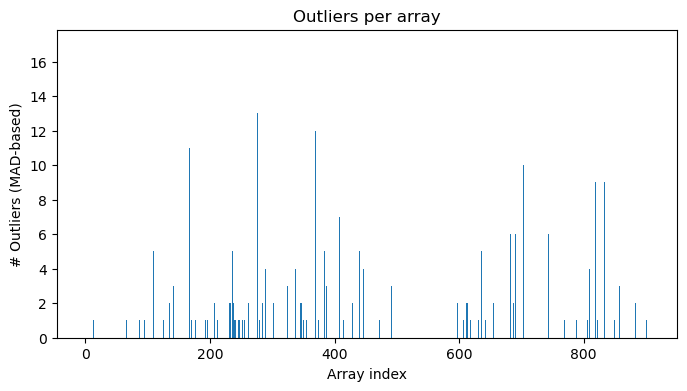

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def robust_z_scores(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) * 1.4826  # 'normal' scale
    return (x - med) / mad if mad != 0 else np.zeros_like(x)

# Compute outlier statistics
threshold = 10
zscores_list = [robust_z_scores(arr[:,0]) for arr in HKS_list]
outlier_masks = [z > threshold for z in zscores_list]
num_outliers = [mask.sum() for mask in outlier_masks]

plt.figure(figsize=(8, 4))
plt.bar(range(len(HKS_list)), num_outliers)
plt.xlabel("Array index")
plt.ylabel("# Outliers (MAD-based)")
plt.title("Outliers per array")
plt.show()


In [43]:
n_defect_thresh = 3

G_list = []

for i, (hks, mask) in enumerate(zip(HKS_list, outlier_masks)):
    if not mask.any() or sum(mask) > n_defect_thresh:
        G = hks_to_curv_proxy_single_t(hks[:,0], t=t_HKS[0])  # (N,)
        G_list.append(G)
    else:
        # approximate curvature f defect from higher t HKS
        G0 = hks_to_curv_proxy_single_t(hks[:,0], t=t_HKS[0])  # (N,)
        G1 = hks_to_curv_proxy_single_t(hks[:,2], t=t_HKS[2])  # (N,)

        G0[mask] = G1[mask]
        G_list.append(G0)


In [44]:
j = 0 

for i, (G, centroids, graph, label, mask) in enumerate(zip(G_list, centroids_list, cell_graphs_list, label_uid_list, outlier_masks)):    
    if not mask.any():
        continue  # skip arrays without defects

    j += 1
    if j >= 10 and j < 20:

        fig = plot_organoid_graph(
            centroids,
            graph,
            node_values=G-np.mean(G), 
        )
        fig.update_layout(title=f"{label}, number of defects = {sum(mask)}")

        fig.show()
 